# 📊 Olist E-Commerce Analytics: Business Intelligence & Customer Insights

### Project Objective

The objective of this project is to perform an end-to-end exploratory data analysis on the Olist Brazilian E-Commerce dataset to uncover insights related to sales performance, customer behavior, product trends, seller performance, payment preferences, logistics efficiency, and customer satisfaction.

The analysis aims to support data-driven business decisions by identifying operational trends, customer patterns, and opportunities for business improvement.

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Data Loading

In this section, the integrated master dataset is loaded for analysis. This dataset combines customer, order, product, seller, payment, and review information into a single analytical table.

In [24]:
master_df = pd.read_csv("../data/processed/master_df.csv")

Initial Data Exploration

Before performing business analysis, the dataset is inspected to understand its structure, dimensions, data types, summary statistics, and any remaining missing values.

In [25]:
master_df.shape

(119143, 39)

In [26]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [27]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [28]:
master_df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,review_score
count,119143.000000,118310.000000,118310.000000,118310.000000,116601.000000,116601.000000,116601.000000,118290.000000,118290.000000,118290.000000,118290.000000,118310.000000,119140.000000,119140.000000,119140.000000,118146.000000
mean,35033.451298,1.196543,120.646603,20.032387,48.767498,785.967822,2.205161,2112.250740,30.265145,16.619706,23.074799,24442.410413,1.094737,2.941246,172.735135,4.015582
std,29823.198969,0.699489,184.109691,15.836850,10.033540,652.584121,1.717452,3786.695111,16.189367,13.453584,11.749139,27573.004511,0.730141,2.777848,267.776077,1.400436
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,1.000000
25%,11250.000000,1.000000,39.900000,13.080000,42.000000,346.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,4.000000
50%,24240.000000,1.000000,74.900000,16.280000,52.000000,600.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.160000,5.000000
75%,58475.000000,1.000000,134.900000,21.180000,57.000000,983.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,27972.000000,1.000000,4.000000,189.240000,5.000000
max,99990.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,29.000000,24.000000,13664.080000,5.000000


In [29]:
master_df.isnull().sum().sort_values(ascending=False)

review_comment_title             105154
review_comment_message            68898
order_delivered_customer_date      3421
product_name_lenght                2542
product_category_name              2542
product_photos_qty                 2542
product_description_lenght         2542
order_delivered_carrier_date       2086
review_creation_date                997
review_score                        997
review_id                           997
review_answer_timestamp             997
product_width_cm                    853
product_weight_g                    853
product_height_cm                   853
product_length_cm                   853
seller_state                        833
seller_city                         833
seller_zip_code_prefix              833
product_id                          833
order_item_id                       833
freight_value                       833
price                               833
shipping_limit_date                 833
seller_id                           833


In [32]:
master_df["price"].sum()

np.float64(14273699.65)

In [31]:
master_df["order_id"].nunique()

99441

In [33]:
master_df["customer_unique_id"].nunique()

96096

In [34]:
master_df["seller_id"].nunique()

3095

In [35]:
master_df.groupby("order_id")["price"].sum().mean()

np.float64(143.53938164338655)

In [36]:
master_df["order_status"].value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

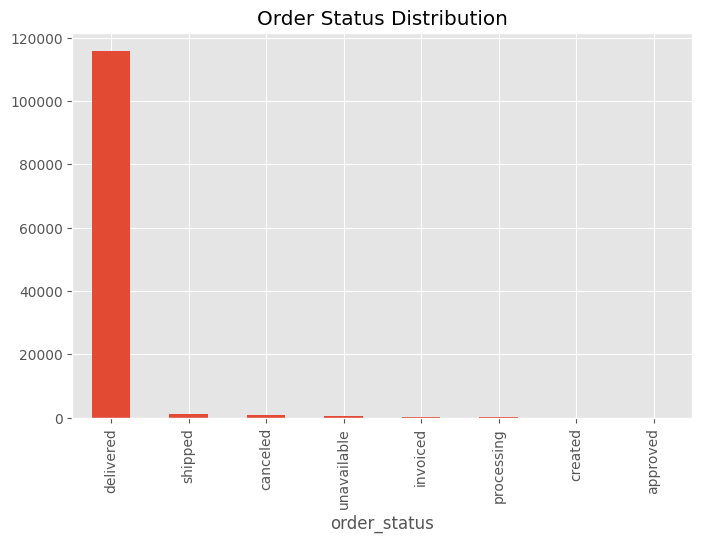

In [37]:
master_df["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Order Status Distribution")
plt.show()

# 4. Sales Trend Analysis

Understanding sales trends over time helps identify seasonal demand, purchasing behavior, and business growth patterns.

This section analyzes:
- Monthly revenue
- Monthly order volume
- Revenue by weekday
- Average order value over time

In [38]:
category_sales = (
    master_df
    .groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_sales.head(10)

product_category_name
beleza_saude              1301947.97
relogios_presentes        1254322.95
cama_mesa_banho           1107249.09
esporte_lazer             1029603.88
informatica_acessorios     950053.69
moveis_decoracao           772096.17
utilidades_domesticas      668880.94
cool_stuff                 664637.13
automotivo                 618395.50
ferramentas_jardim         519473.33
Name: price, dtype: float64

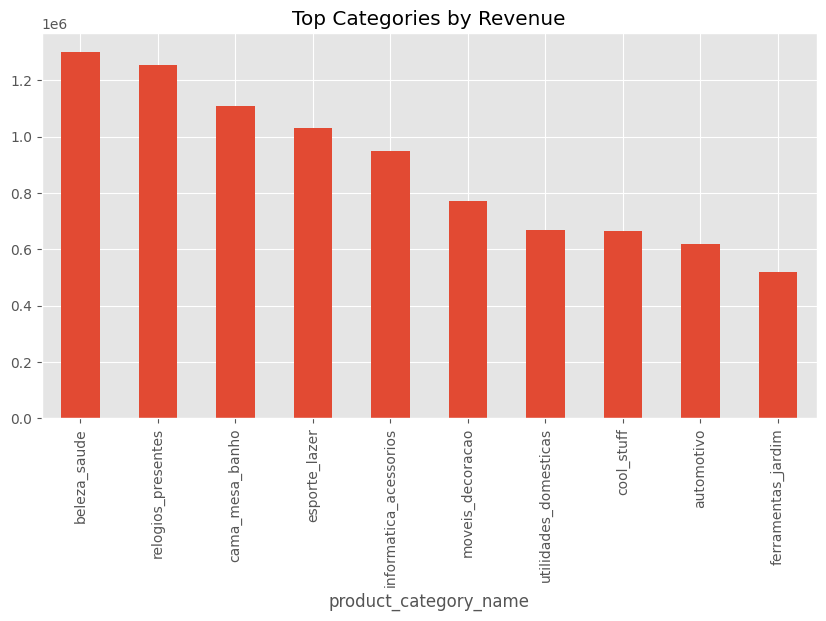

In [39]:
category_sales.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Categories by Revenue")
plt.show()

In [40]:
master_df["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           11988
beleza_saude              10032
esporte_lazer              9004
moveis_decoracao           8832
informatica_acessorios     8150
utilidades_domesticas      7380
relogios_presentes         6213
telefonia                  4726
ferramentas_jardim         4590
automotivo                 4400
Name: count, dtype: int64

In [41]:
top_sellers = (
    master_df.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

top_sellers.head(10)

seller_id
53243585a1d6dc2643021fd1853d8905    244627.55
4869f7a5dfa277a7dca6462dcf3b52b2    237867.23
4a3ca9315b744ce9f8e9374361493884    215825.77
fa1c13f2614d7b5c4749cbc52fecda94    203984.22
7c67e1448b00f6e969d365cea6b010ab    199688.11
7e93a43ef30c4f03f38b393420bc753a    182878.17
da8622b14eb17ae2831f4ac5b9dab84a    171784.57
7a67c85e85bb2ce8582c35f2203ad736    150749.79
1025f0e2d44d7041d6cf58b6550e0bfa    143675.53
955fee9216a65b617aa5c0531780ce60    137405.00
Name: price, dtype: float64

In [42]:
master_df["customer_state"].value_counts()

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
PE     1906
CE     1565
MT     1132
PA     1129
MS      862
MA      856
PB      644
PI      576
RN      574
AL      464
SE      403
TO      340
RO      292
AM      173
AC       95
AP       84
RR       52
Name: count, dtype: int64

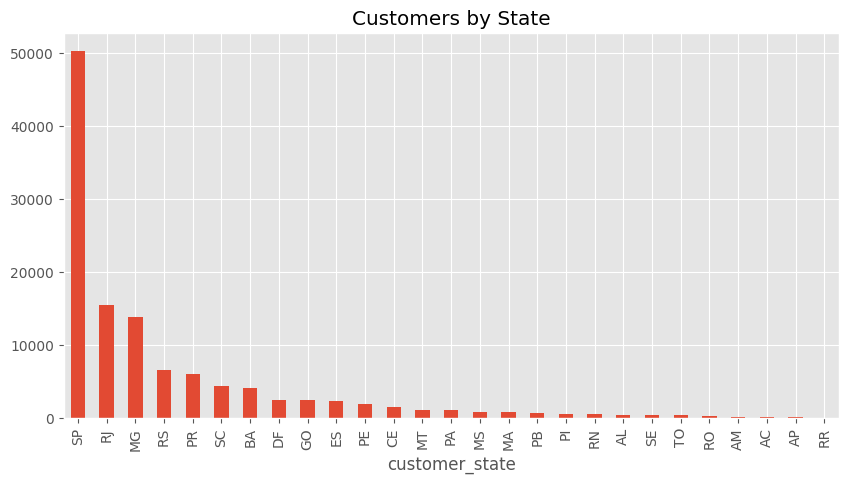

In [43]:
master_df["customer_state"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Customers by State")
plt.show()

In [44]:
master_df["seller_state"].value_counts()

seller_state
SP    84377
MG     9314
PR     9096
RJ     5036
SC     4271
RS     2294
DF      949
BA      700
GO      550
PE      465
MA      410
ES      390
MT      147
CE      103
MS       60
RN       56
PB       44
RO       14
PI       12
SE       10
PA        8
AM        3
AC        1
Name: count, dtype: int64

In [45]:
master_df["payment_type"].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

In [46]:
master_df.groupby("payment_type")["price"].sum()

payment_type
boleto          2405984.26
credit_card    11017976.56
debit_card       184354.31
not_defined           0.00
voucher          665249.55
Name: price, dtype: float64

In [47]:
master_df["payment_installments"].value_counts().sort_index()

payment_installments
0.0         3
1.0     59446
2.0     13838
3.0     11889
4.0      8072
5.0      6097
6.0      4674
7.0      1848
8.0      5120
9.0       739
10.0     6976
11.0       26
12.0      168
13.0       19
14.0       16
15.0       93
16.0        7
17.0        8
18.0       38
20.0       21
21.0        6
22.0        1
23.0        1
24.0       34
Name: count, dtype: int64

In [48]:
master_df["review_score"].value_counts().sort_index()

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

In [49]:
master_df["review_score"].mean()

np.float64(4.015582414978078)

In [51]:
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

In [52]:
master_df["purchase_month"] = (
    master_df["order_purchase_timestamp"]
    .dt.to_period("M")
)

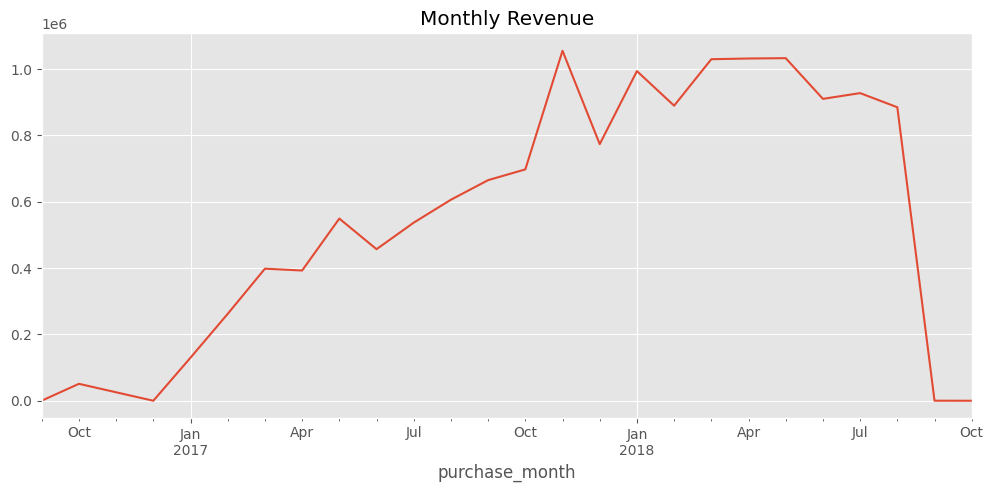

In [53]:
monthly_sales = (
    master_df.groupby("purchase_month")["price"]
    .sum()
)

monthly_sales.plot(figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

In [54]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    master_df[col] = pd.to_datetime(master_df[col])

In [55]:
master_df["delivery_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.days

In [56]:
master_df["delivery_days"].mean()

np.float64(12.022588617548953)

In [57]:
master_df["freight_value"].mean()

np.float64(20.0323865269208)

Correlation Analysis

Correlation analysis helps identify relationships between numerical variables such as product price, freight charges, delivery time, payment value, and customer ratings.

The objective is to understand whether operational metrics influence customer behavior and satisfaction.

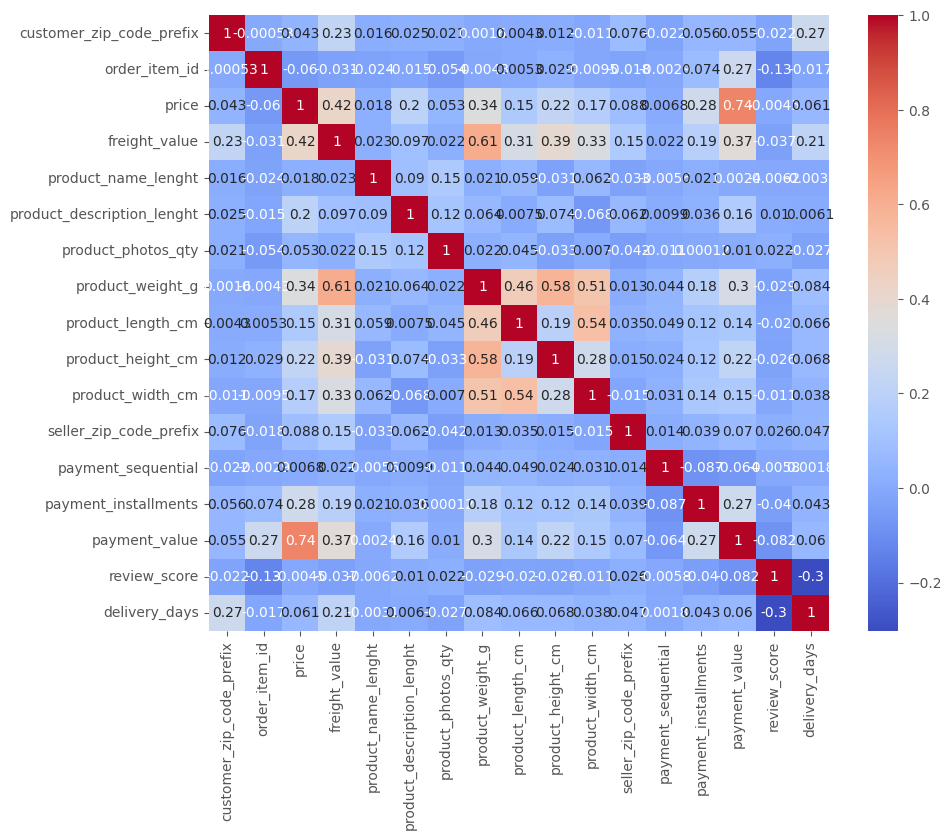

In [58]:
corr = master_df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [59]:
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

In [60]:
master_df["purchase_year"] = master_df["order_purchase_timestamp"].dt.year

master_df["purchase_month"] = master_df["order_purchase_timestamp"].dt.month_name()

master_df["purchase_month_num"] = master_df["order_purchase_timestamp"].dt.month

master_df["purchase_day"] = master_df["order_purchase_timestamp"].dt.day_name()

In [61]:
monthly_sales = (
    master_df.groupby("purchase_month_num")["price"]
    .sum()
    .reset_index()
)

monthly_sales

,purchase_month_num,price
0,1,1123596.81
1,2,1151526.15
2,3,1427707.11
3,4,1424312.98
4,5,1581926.26
5,6,1366920.50
6,7,1464308.34
7,8,1490758.50
8,9,665459.74
9,10,748526.24


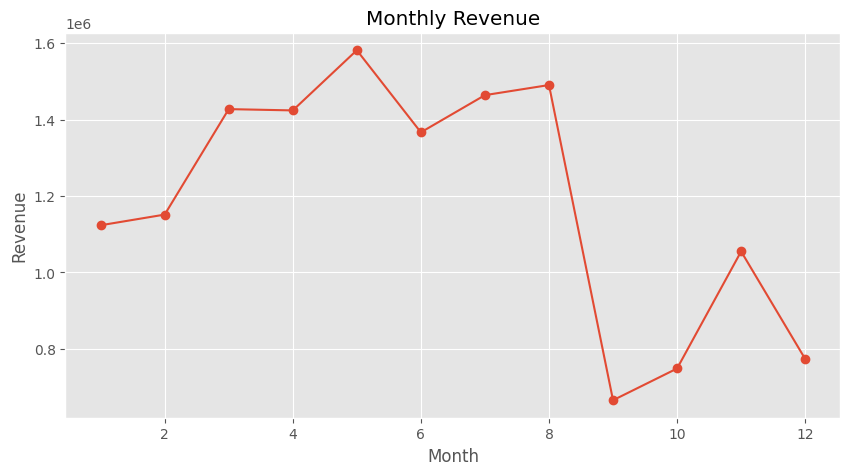

In [62]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["purchase_month_num"],
    monthly_sales["price"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [63]:
monthly_orders = (
    master_df.groupby("purchase_month_num")["order_id"]
    .nunique()
    .reset_index(name="orders")
)

monthly_orders

,purchase_month_num,orders
0,1,8069
1,2,8508
2,3,9893
3,4,9343
4,5,10573
5,6,9412
6,7,10318
7,8,10843
8,9,4305
9,10,4959


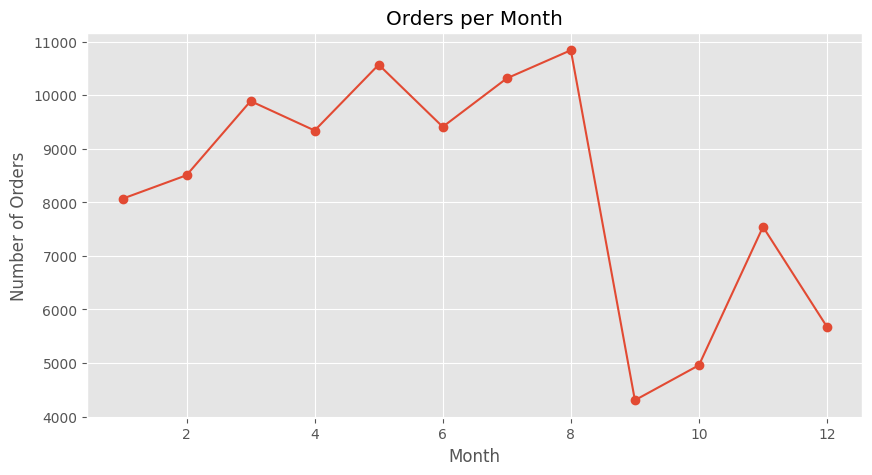

In [64]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_orders["purchase_month_num"],
    monthly_orders["orders"],
    marker="o"
)

plt.title("Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

In [65]:
weekday_sales = (
    master_df.groupby("purchase_day")["price"]
    .sum()
)

weekday_sales = weekday_sales.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

weekday_sales

purchase_day
Monday       2327589.53
Tuesday      2278468.67
Wednesday    2233244.30
Thursday     2135196.30
Friday       2056076.78
Saturday     1580298.96
Sunday       1662825.11
Name: price, dtype: float64

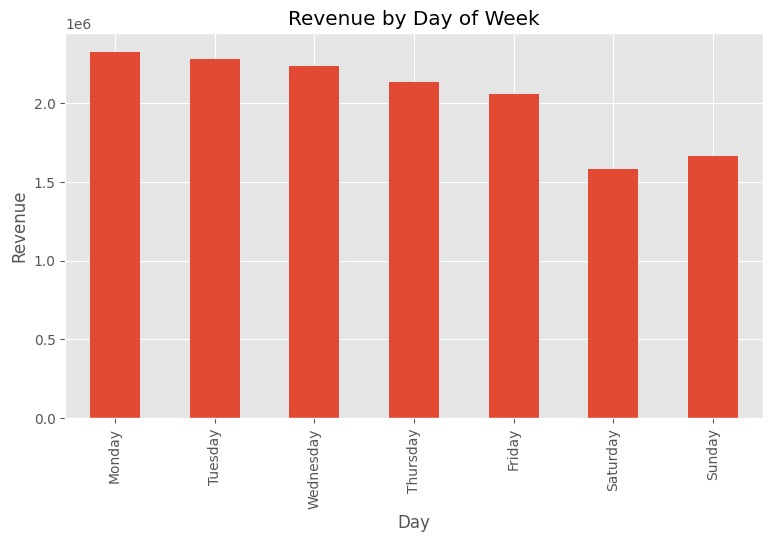

In [66]:
plt.figure(figsize=(9,5))

weekday_sales.plot(kind="bar")

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.show()

In [67]:
monthly_aov = (
    master_df.groupby("purchase_month_num")
    .agg(
        Revenue=("price", "sum"),
        Orders=("order_id", "nunique")
    )
)

monthly_aov["Average_Order_Value"] = (
    monthly_aov["Revenue"] / monthly_aov["Orders"]
)

monthly_aov

,Revenue,Orders,Average_Order_Value
purchase_month_num,,,
1,1123596.81,8069,139.248582
2,1151526.15,8508,135.346280
3,1427707.11,9893,144.314880
4,1424312.98,9343,152.447071
5,1581926.26,10573,149.619433
6,1366920.50,9412,145.231672
7,1464308.34,10318,141.917846
8,1490758.50,10843,137.485797
9,665459.74,4305,154.578337


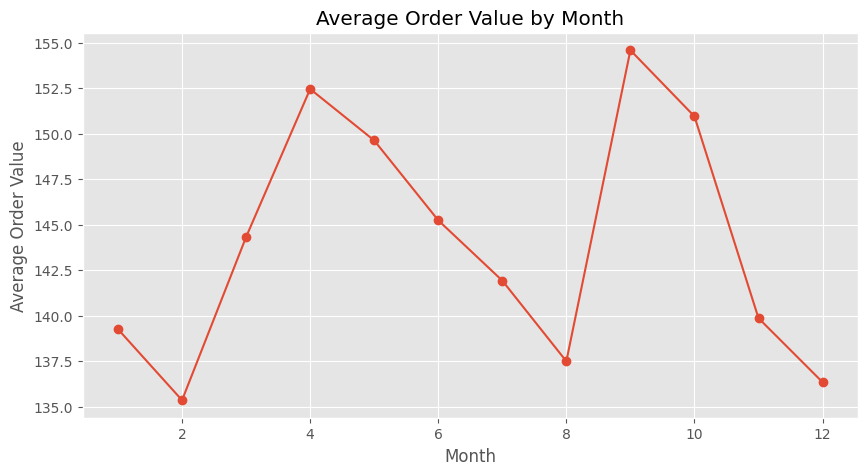

In [68]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_aov.index,
    monthly_aov["Average_Order_Value"],
    marker="o"
)

plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.show()

In [69]:
category_revenue = (
    master_df.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue.head(10)

product_category_name
beleza_saude              1301947.97
relogios_presentes        1254322.95
cama_mesa_banho           1107249.09
esporte_lazer             1029603.88
informatica_acessorios     950053.69
moveis_decoracao           772096.17
utilidades_domesticas      668880.94
cool_stuff                 664637.13
automotivo                 618395.50
ferramentas_jardim         519473.33
Name: price, dtype: float64

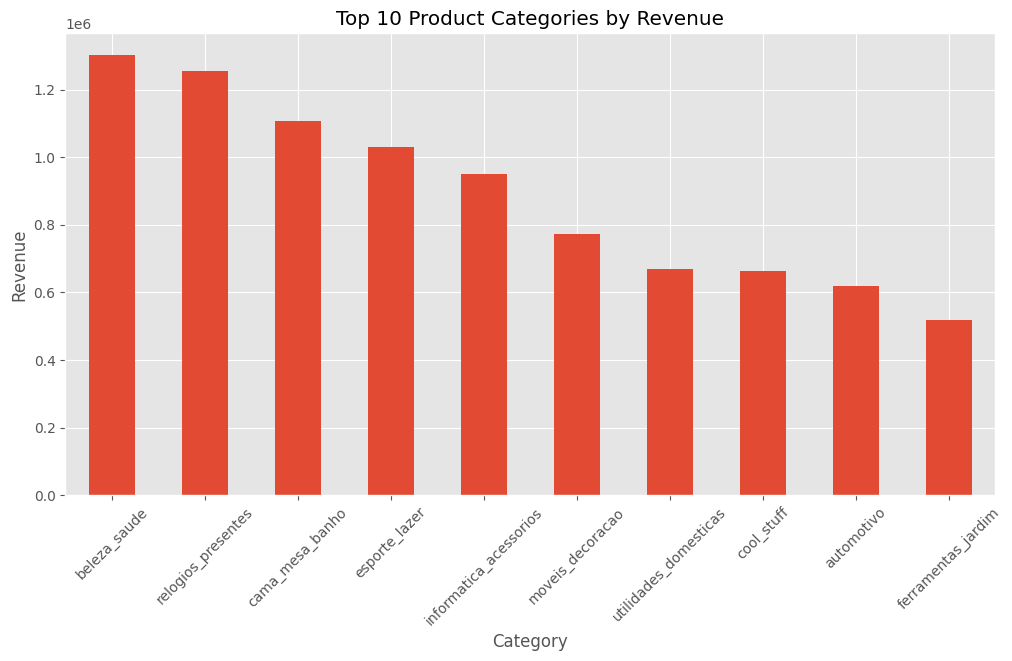

In [70]:
plt.figure(figsize=(12,6))

category_revenue.head(10).plot(kind="bar")

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [71]:
category_orders = (
    master_df.groupby("product_category_name")["order_item_id"]
    .count()
    .sort_values(ascending=False)
)

category_orders.head(10)

product_category_name
cama_mesa_banho           11988
beleza_saude              10032
esporte_lazer              9004
moveis_decoracao           8832
informatica_acessorios     8150
utilidades_domesticas      7380
relogios_presentes         6213
telefonia                  4726
ferramentas_jardim         4590
automotivo                 4400
Name: order_item_id, dtype: int64

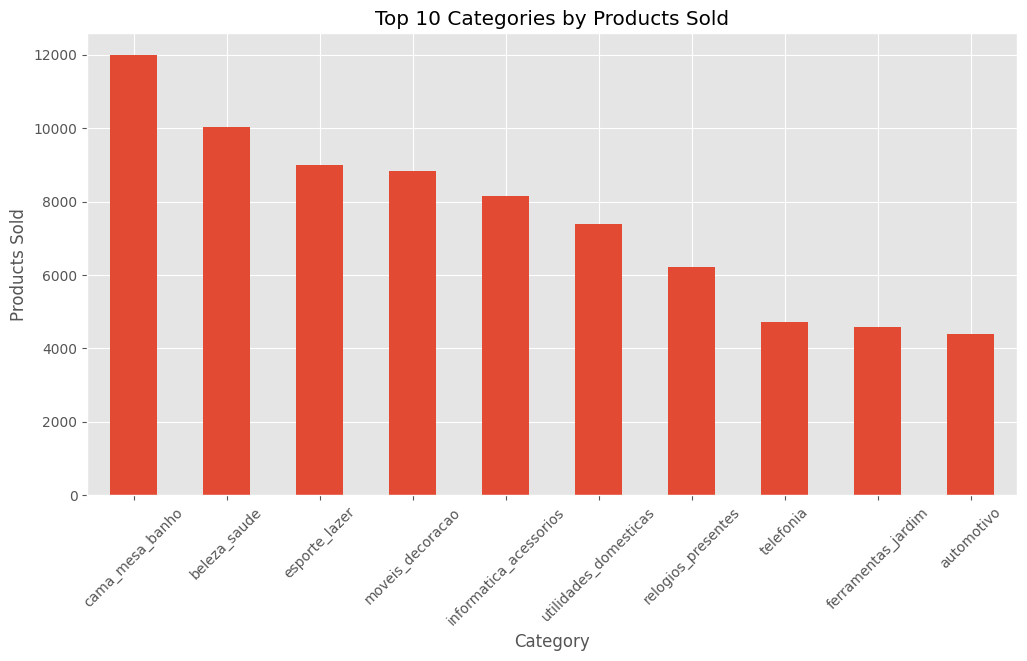

In [72]:
plt.figure(figsize=(12,6))

category_orders.head(10).plot(kind="bar")

plt.title("Top 10 Categories by Products Sold")
plt.xlabel("Category")
plt.ylabel("Products Sold")

plt.xticks(rotation=45)

plt.show()

In [73]:
avg_price = (
    master_df.groupby("product_category_name")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price.head(10)

product_category_name
pcs                                              1103.689136
portateis_casa_forno_e_cafe                       627.509103
eletrodomesticos_2                                457.529481
agro_industria_e_comercio                         332.706151
instrumentos_musicais                             293.398651
eletroportateis                                   286.297248
portateis_cozinha_e_preparadores_de_alimentos     264.568667
telefonia_fixa                                    226.989890
construcao_ferramentas_seguranca                  210.942261
relogios_presentes                                201.886842
Name: price, dtype: float64

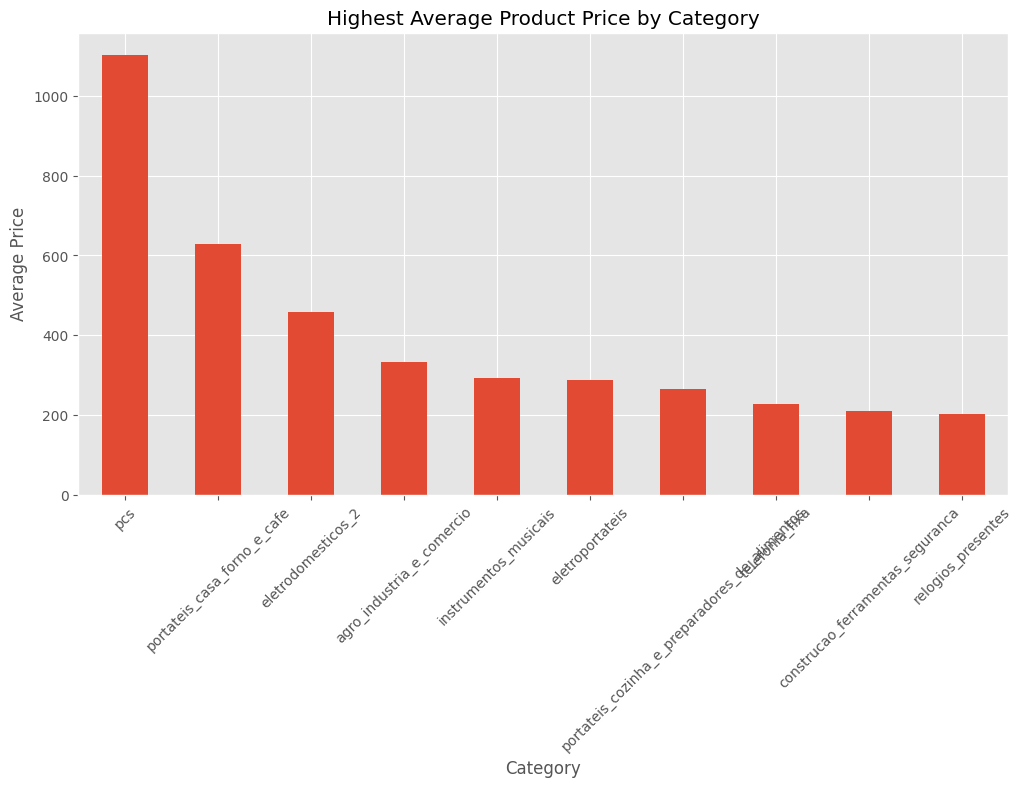

In [74]:
plt.figure(figsize=(12,6))

avg_price.head(10).plot(kind="bar")

plt.title("Highest Average Product Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

In [75]:
avg_freight = (
    master_df.groupby("product_category_name")["freight_value"]
    .mean()
    .sort_values(ascending=False)
)

avg_freight.head(10)

product_category_name
pcs                                               48.012727
eletrodomesticos_2                                45.970667
moveis_quarto                                     44.180000
moveis_cozinha_area_de_servico_jantar_e_jardim    42.485351
moveis_colchao_e_estofado                         41.771951
moveis_escritorio                                 40.128003
portateis_casa_forno_e_cafe                       36.982821
moveis_sala                                       35.766861
sinalizacao_e_seguranca                           32.517512
industria_comercio_e_negocios                     29.330699
Name: freight_value, dtype: float64

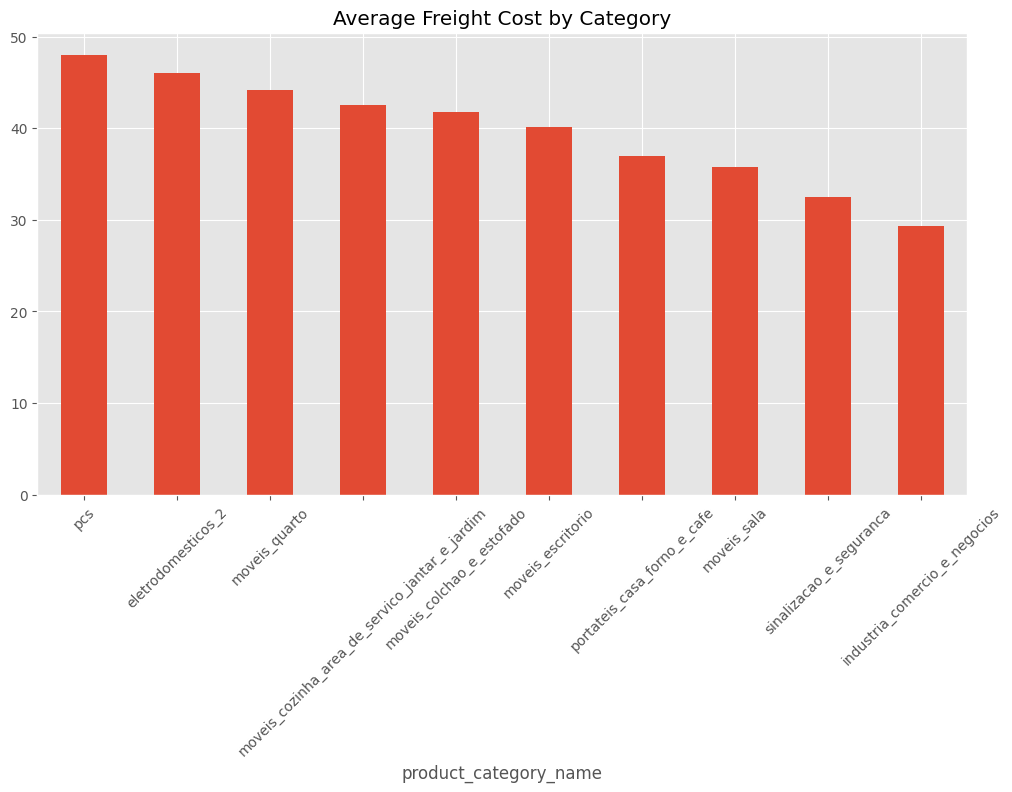

In [76]:
plt.figure(figsize=(12,6))

avg_freight.head(10).plot(kind="bar")

plt.title("Average Freight Cost by Category")

plt.xticks(rotation=45)

plt.show()

In [77]:
top_products = (
    master_df.groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

top_products.head(10)

product_id
bb50f2e236e5eea0100680137654686c    68810.00
d6160fb7873f184099d9bc95e30376af    56948.83
6cdd53843498f92890544667809f1595    55779.90
d1c427060a0f73f6b889a5c7c61f2ac4    49141.40
99a4788cb24856965c36a24e339b6058    46575.66
25c38557cf793876c5abdd5931f922db    44829.32
3dd2a17168ec895c781a9191c1e95ad7    41682.20
aca2eb7d00ea1a7b8ebd4e68314663af    38248.20
53b36df67ebb7c41585e8d54d6772e08    38158.21
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
Name: price, dtype: float64

In [78]:
popular_products = (
    master_df.groupby("product_id")["order_item_id"]
    .count()
    .sort_values(ascending=False)
)

popular_products.head(10)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    536
99a4788cb24856965c36a24e339b6058    528
422879e10f46682990de24d770e7f83d    508
389d119b48cf3043d311335e499d9c6b    406
368c6c730842d78016ad823897a372db    398
53759a2ecddad2bb87a079a1f1519f73    391
d1c427060a0f73f6b889a5c7c61f2ac4    357
53b36df67ebb7c41585e8d54d6772e08    327
154e7e31ebfa092203795c972e5804a6    295
3dd2a17168ec895c781a9191c1e95ad7    278
Name: order_item_id, dtype: int64

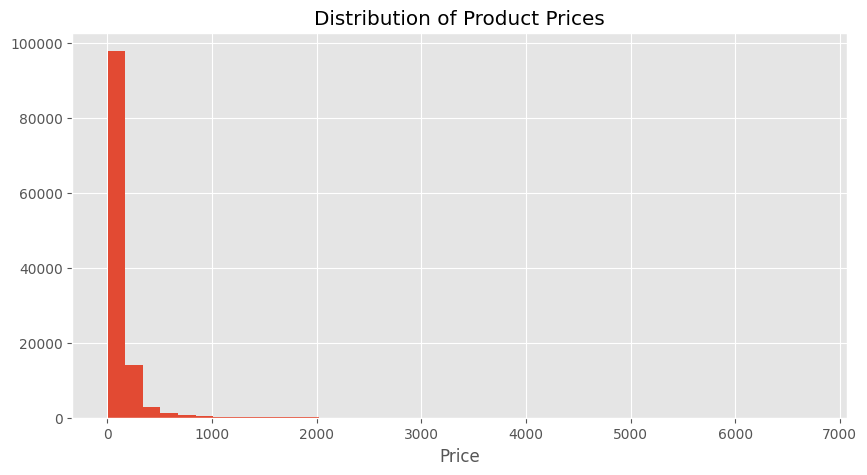

In [79]:
plt.figure(figsize=(10,5))

master_df["price"].hist(bins=40)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")

plt.show()

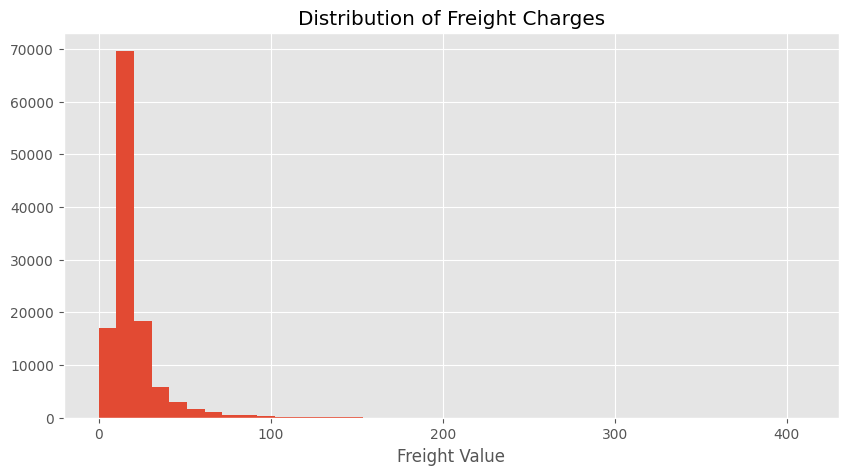

In [80]:
plt.figure(figsize=(10,5))

master_df["freight_value"].hist(bins=40)

plt.title("Distribution of Freight Charges")
plt.xlabel("Freight Value")

plt.show()

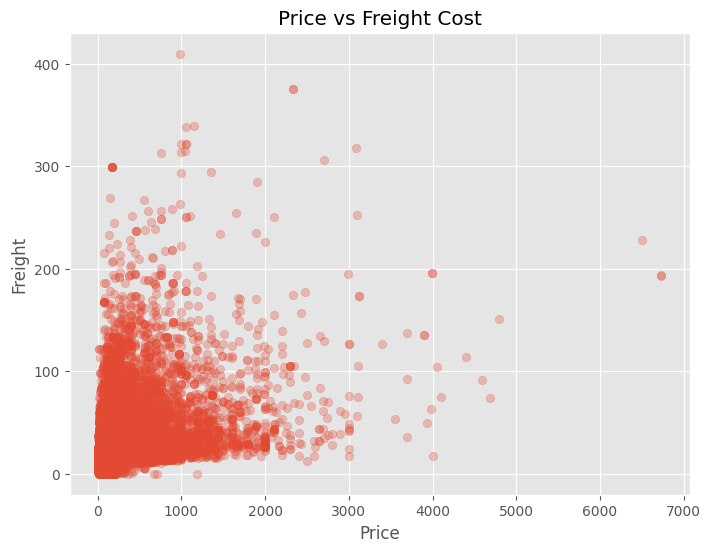

In [81]:
plt.figure(figsize=(8,6))

plt.scatter(
    master_df["price"],
    master_df["freight_value"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Freight")

plt.title("Price vs Freight Cost")

plt.show()

In [82]:
master_df[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.415938
freight_value,0.415938,1.000000


In [83]:
top_sellers = (
    master_df.groupby("seller_id")["price"]
    .sum()
    .sort_values(ascending=False)
)

top_sellers.head(10)

seller_id
53243585a1d6dc2643021fd1853d8905    244627.55
4869f7a5dfa277a7dca6462dcf3b52b2    237867.23
4a3ca9315b744ce9f8e9374361493884    215825.77
fa1c13f2614d7b5c4749cbc52fecda94    203984.22
7c67e1448b00f6e969d365cea6b010ab    199688.11
7e93a43ef30c4f03f38b393420bc753a    182878.17
da8622b14eb17ae2831f4ac5b9dab84a    171784.57
7a67c85e85bb2ce8582c35f2203ad736    150749.79
1025f0e2d44d7041d6cf58b6550e0bfa    143675.53
955fee9216a65b617aa5c0531780ce60    137405.00
Name: price, dtype: float64

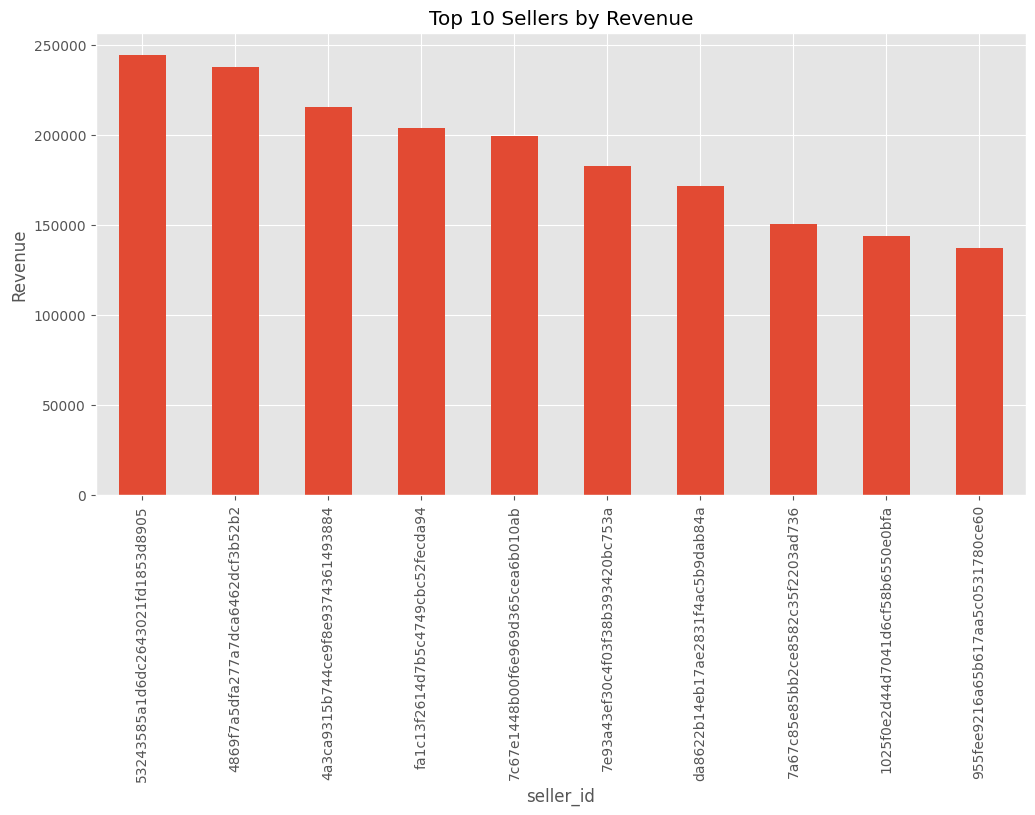

In [84]:
plt.figure(figsize=(12,6))

top_sellers.head(10).plot(kind="bar")

plt.title("Top 10 Sellers by Revenue")
plt.ylabel("Revenue")

plt.show()

In [85]:
seller_orders = (
    master_df.groupby("seller_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

seller_orders.head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64

In [86]:
seller_state_revenue = (
    master_df.groupby("seller_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

seller_state_revenue

seller_state
SP    9175351.45
PR    1334148.97
MG    1063158.33
RJ     871999.54
SC     662934.93
RS     394201.84
BA     321267.69
DF     106756.59
PE     100578.94
GO      69978.43
ES      49195.87
MA      36786.90
CE      20621.36
PB      17379.40
MT      17373.72
MS      10400.69
RN       9992.60
RO       4762.20
PI       2522.00
SE       1606.20
PA       1238.00
AM       1177.00
AC        267.00
Name: price, dtype: float64

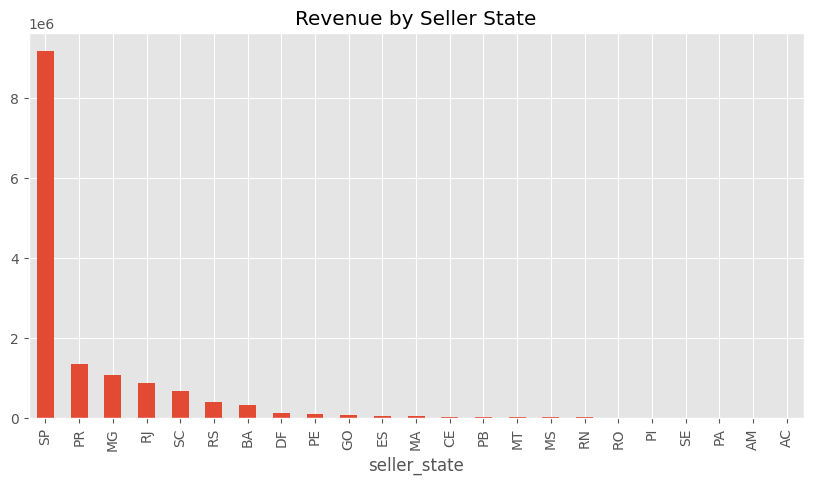

In [87]:
plt.figure(figsize=(10,5))

seller_state_revenue.plot(kind="bar")

plt.title("Revenue by Seller State")

plt.show()

In [88]:
seller_count = (
    master_df.groupby("seller_state")["seller_id"]
    .nunique()
    .sort_values(ascending=False)
)

seller_count

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
MS       5
RN       5
MT       4
RO       2
SE       2
AC       1
PI       1
AM       1
MA       1
PA       1
Name: seller_id, dtype: int64

In [89]:
seller_avg = (
    master_df.groupby("seller_id")["price"]
    .sum()
    .mean()
)

seller_avg

np.float64(4611.857722132472)

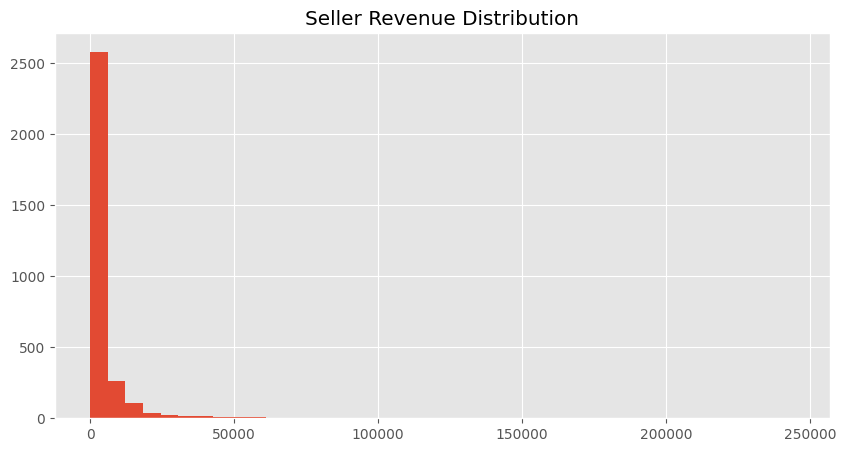

In [90]:
plt.figure(figsize=(10,5))

master_df.groupby("seller_id")["price"].sum().hist(bins=40)

plt.title("Seller Revenue Distribution")

plt.show()

In [91]:
customer_state = (
    master_df.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

customer_state

customer_state
SP    40302
RJ    12384
MG    11259
RS     5277
PR     4882
SC     3534
BA     3277
DF     2075
ES     1964
GO     1952
PE     1609
CE     1313
PA      949
MT      876
MA      726
MS      694
PB      519
PI      482
RN      474
AL      401
SE      342
TO      273
RO      240
AM      143
AC       77
AP       67
RR       45
Name: customer_unique_id, dtype: int64

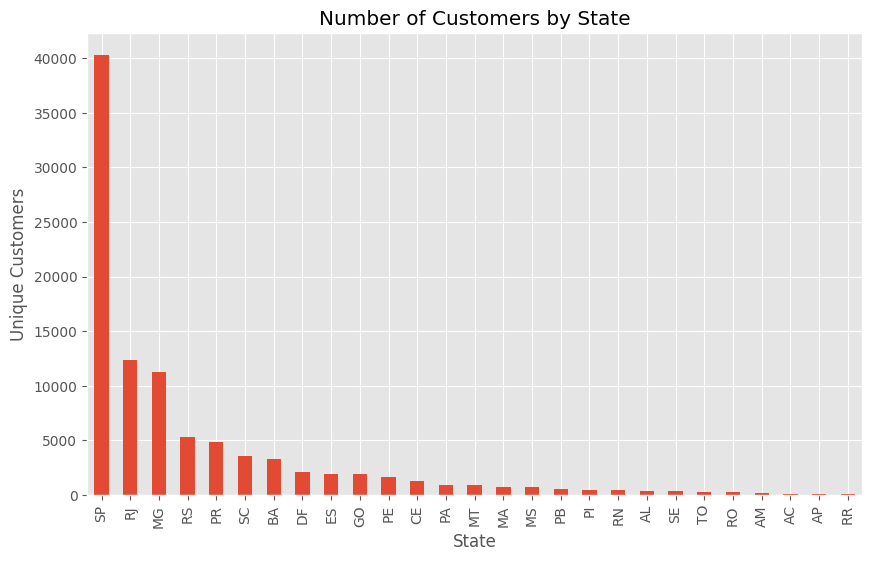

In [92]:
plt.figure(figsize=(10,6))

customer_state.plot(kind="bar")

plt.title("Number of Customers by State")
plt.xlabel("State")
plt.ylabel("Unique Customers")

plt.show()

In [93]:
customer_city = (
    master_df.groupby("customer_city")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
)

customer_city.head(10)

customer_city
sao paulo                14984
rio de janeiro            6620
belo horizonte            2672
brasilia                  2069
curitiba                  1465
campinas                  1398
porto alegre              1326
salvador                  1209
guarulhos                 1153
sao bernardo do campo      908
Name: customer_unique_id, dtype: int64

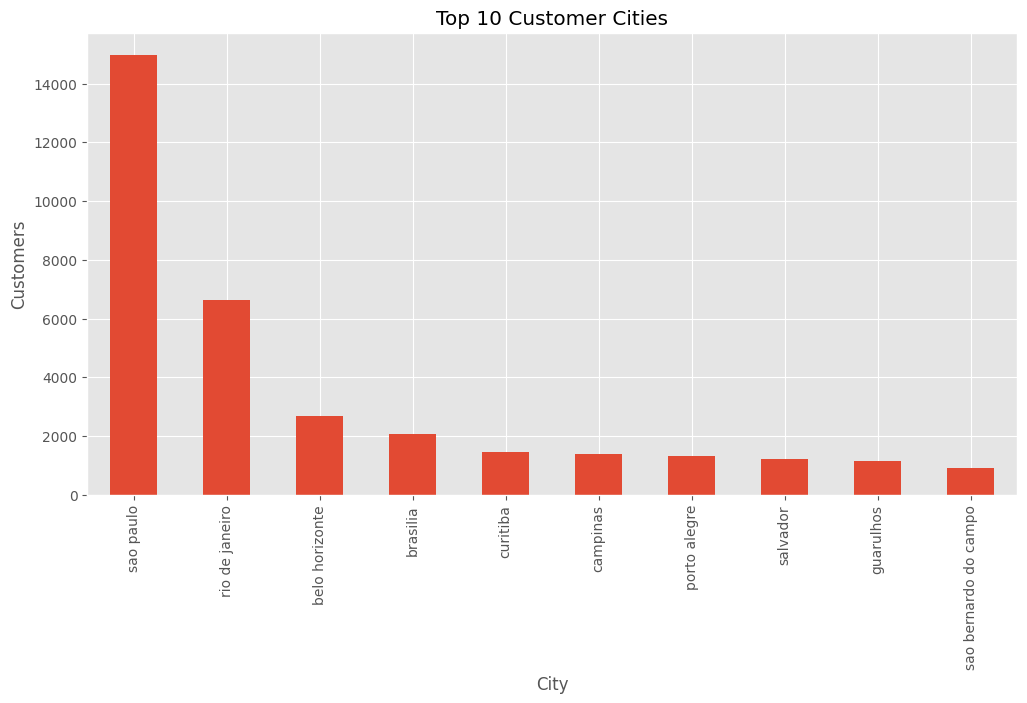

In [94]:
plt.figure(figsize=(12,6))

customer_city.head(10).plot(kind="bar")

plt.title("Top 10 Customer Cities")

plt.xlabel("City")

plt.ylabel("Customers")

plt.show()

In [95]:
state_revenue = (
    master_df.groupby("customer_state")["price"]
    .sum()
    .sort_values(ascending=False)
)

state_revenue

customer_state
SP    5477008.74
RJ    1921752.53
MG    1645847.27
RS     791716.84
PR     708794.22
BA     543243.99
SC     539896.20
DF     315122.29
GO     313198.27
ES     284771.30
PE     272271.97
CE     240095.13
PA     184889.93
MT     171109.74
PB     123816.24
MA     123077.67
MS     121358.47
RN      94607.86
PI      92227.70
AL      83314.32
SE      60954.60
TO      56251.91
RO      46964.03
AM      22865.26
AC      17059.44
AP      13654.30
RR       7829.43
Name: price, dtype: float64

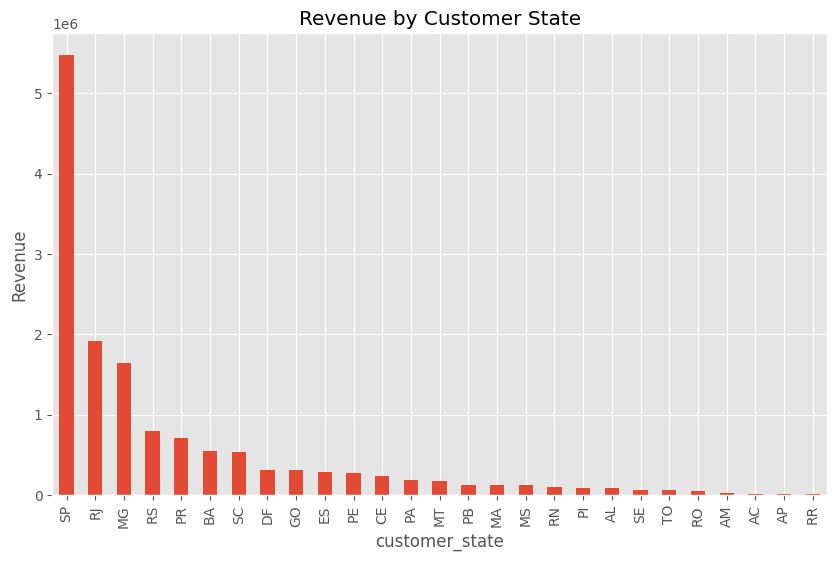

In [96]:
plt.figure(figsize=(10,6))

state_revenue.plot(kind="bar")

plt.title("Revenue by Customer State")

plt.ylabel("Revenue")

plt.show()

In [97]:
customer_spending = (
    master_df.groupby("customer_unique_id")["price"]
    .sum()
)

customer_spending.describe()

count    96096.000000
mean       148.535836
std        249.358758
min          0.000000
25%         47.900000
50%         89.900000
75%        159.900000
max      13440.000000
Name: price, dtype: float64

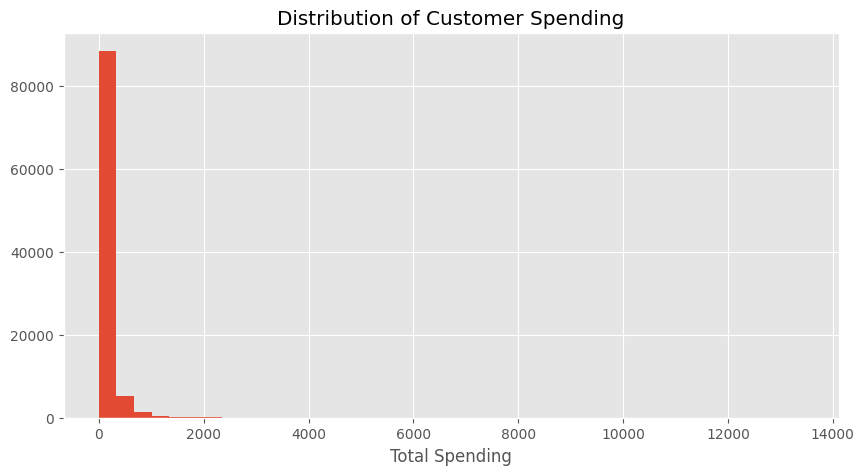

In [98]:
plt.figure(figsize=(10,5))

customer_spending.hist(bins=40)

plt.title("Distribution of Customer Spending")

plt.xlabel("Total Spending")

plt.show()

In [99]:
top_customers = (
    customer_spending
    .sort_values(ascending=False)
)

top_customers.head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.00
8af7ac63b2efbcbd88e5b11505e8098a    11383.95
c4b224d2c784bae11ae98b6ae9f2454c    10856.10
85963fd37bfd387aa6d915d8a1065486     9888.00
be74c431147c32ab2d7c7cef5e4a995f     9520.14
edf81e1f3070b9dac83ec83dacdbb9bc     7998.00
1033eef37a760a832f9b2332ce23fdc5     7799.40
58483a1c055dfb600f57c5b867174542     7798.00
da122df9eeddfedc1dc1f5349a1a690c     7388.00
763c8b1c9c68a0229c42c9fc6f662b93     7160.00
Name: price, dtype: float64

In [100]:
repeat_customers = (
    master_df.groupby("customer_unique_id")["order_id"]
    .nunique()
)

repeat_customers.describe()

count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_id, dtype: float64

In [101]:
repeat_customers[
    repeat_customers > 1
].count()

np.int64(2997)

In [102]:
repeat_percentage = (
    (repeat_customers > 1).sum()
    / repeat_customers.count()
) * 100

print(f"Repeat Customers: {repeat_percentage:.2f}%")

Repeat Customers: 3.12%


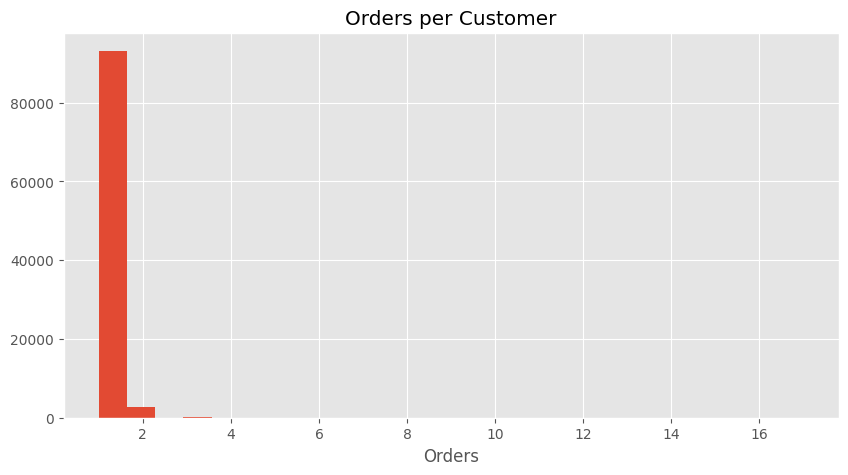

In [103]:
plt.figure(figsize=(10,5))

repeat_customers.hist(bins=25)

plt.title("Orders per Customer")

plt.xlabel("Orders")

plt.show()

In [104]:
customer_clv = (
    master_df.groupby("customer_unique_id")["price"]
    .sum()
)

customer_clv.describe()

count    96096.000000
mean       148.535836
std        249.358758
min          0.000000
25%         47.900000
50%         89.900000
75%        159.900000
max      13440.000000
Name: price, dtype: float64

In [105]:
customer_clv.sort_values(
    ascending=False
).head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13440.00
8af7ac63b2efbcbd88e5b11505e8098a    11383.95
c4b224d2c784bae11ae98b6ae9f2454c    10856.10
85963fd37bfd387aa6d915d8a1065486     9888.00
be74c431147c32ab2d7c7cef5e4a995f     9520.14
edf81e1f3070b9dac83ec83dacdbb9bc     7998.00
1033eef37a760a832f9b2332ce23fdc5     7799.40
58483a1c055dfb600f57c5b867174542     7798.00
da122df9eeddfedc1dc1f5349a1a690c     7388.00
763c8b1c9c68a0229c42c9fc6f662b93     7160.00
Name: price, dtype: float64

In [106]:
master_df["customer_total_spending"] = (
    master_df.groupby("customer_unique_id")["price"]
    .transform("sum")
)

In [107]:
master_df["customer_segment"] = pd.qcut(
    master_df["customer_total_spending"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Premium"
    ]
)

In [108]:
master_df["customer_segment"].value_counts()

customer_segment
Medium     29886
Low        29828
Premium    29769
High       29660
Name: count, dtype: int64

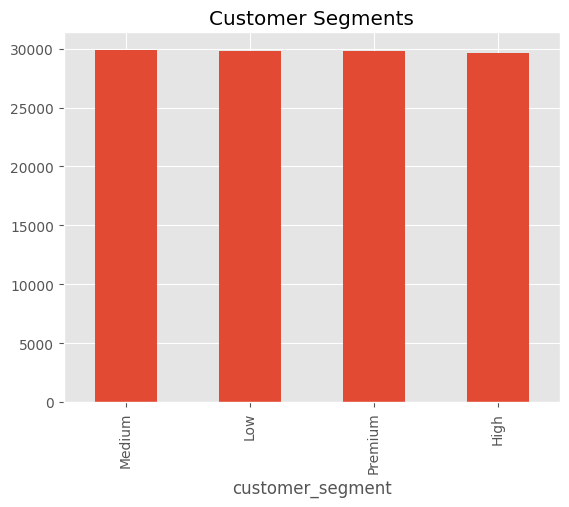

In [109]:
master_df["customer_segment"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Segments")

plt.show()

In [110]:
payment_method = (
    master_df.groupby("payment_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

payment_method

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
not_defined        3
Name: order_id, dtype: int64

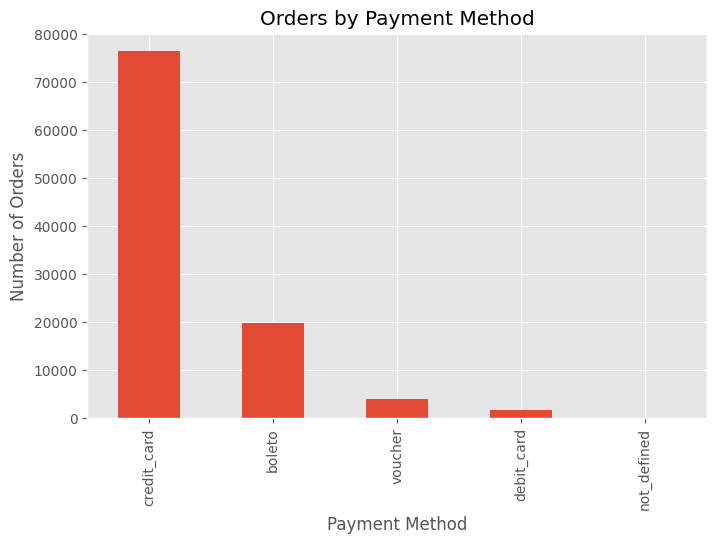

In [111]:
plt.figure(figsize=(8,5))

payment_method.plot(kind="bar")

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.show()

In [112]:
payment_revenue = (
    master_df.groupby("payment_type")["price"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

payment_type
credit_card    11017976.56
boleto          2405984.26
voucher          665249.55
debit_card       184354.31
not_defined           0.00
Name: price, dtype: float64

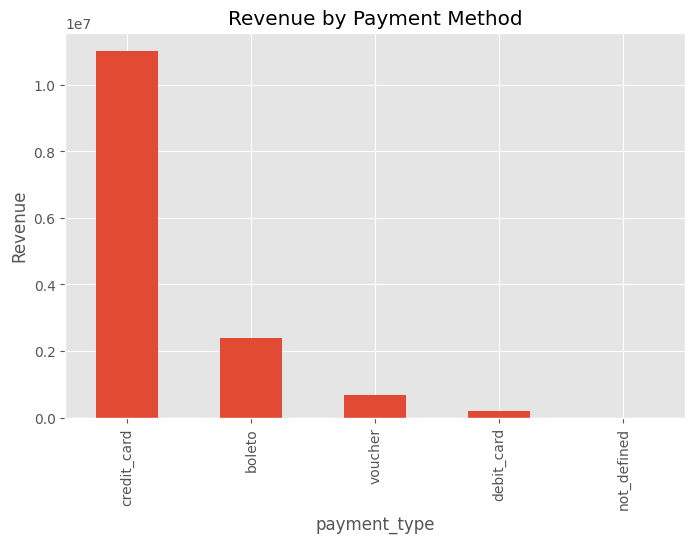

In [113]:
plt.figure(figsize=(8,5))

payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Method")

plt.ylabel("Revenue")

plt.show()

In [114]:
installments = (
    master_df["payment_installments"]
    .value_counts()
    .sort_index()
)

installments

payment_installments
0.0         3
1.0     59446
2.0     13838
3.0     11889
4.0      8072
5.0      6097
6.0      4674
7.0      1848
8.0      5120
9.0       739
10.0     6976
11.0       26
12.0      168
13.0       19
14.0       16
15.0       93
16.0        7
17.0        8
18.0       38
20.0       21
21.0        6
22.0        1
23.0        1
24.0       34
Name: count, dtype: int64

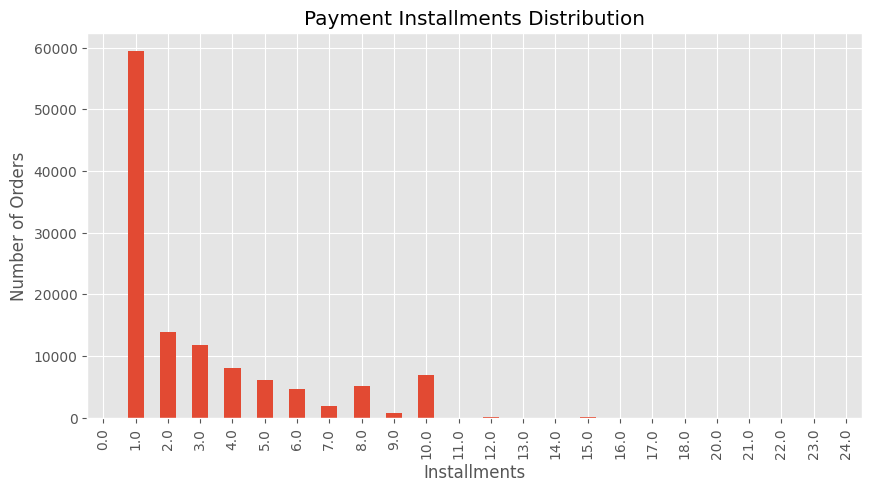

In [115]:
plt.figure(figsize=(10,5))

installments.plot(kind="bar")

plt.title("Payment Installments Distribution")

plt.xlabel("Installments")

plt.ylabel("Number of Orders")

plt.show()

In [116]:
avg_payment = (
    master_df.groupby("payment_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_payment

payment_type
credit_card    126.268956
debit_card     108.507540
voucher        105.061521
boleto         104.526208
not_defined           NaN
Name: price, dtype: float64

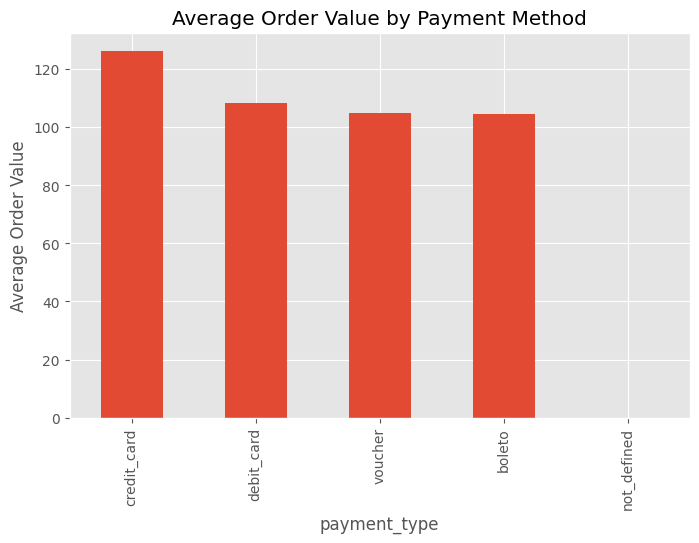

In [117]:
plt.figure(figsize=(8,5))

avg_payment.plot(kind="bar")

plt.title("Average Order Value by Payment Method")

plt.ylabel("Average Order Value")

plt.show()

In [118]:
installment_value = (
    master_df.groupby("payment_installments")["price"]
    .mean()
)

installment_value

payment_installments
0.0      43.093333
1.0      91.122470
2.0      97.712107
3.0     108.060639
4.0     125.677512
5.0     138.886609
6.0     155.834356
7.0     144.739499
8.0     236.409759
9.0     150.788918
10.0    290.596304
11.0     86.366000
12.0    224.305663
13.0    109.994211
14.0    142.880625
15.0    327.159462
16.0    185.542857
17.0    149.745714
18.0    323.891316
20.0    454.431429
21.0    125.783333
22.0    209.990000
23.0    216.000000
24.0    293.281176
Name: price, dtype: float64

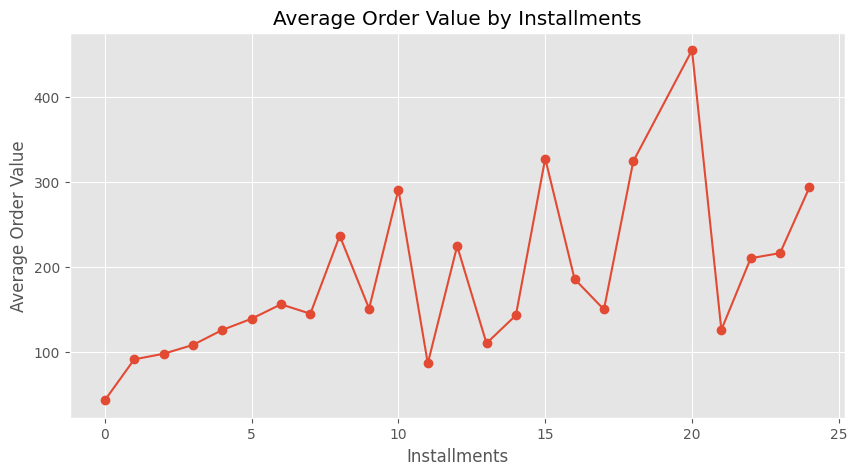

In [119]:
plt.figure(figsize=(10,5))

plt.plot(
    installment_value.index,
    installment_value.values,
    marker="o"
)

plt.title("Average Order Value by Installments")

plt.xlabel("Installments")

plt.ylabel("Average Order Value")

plt.show()

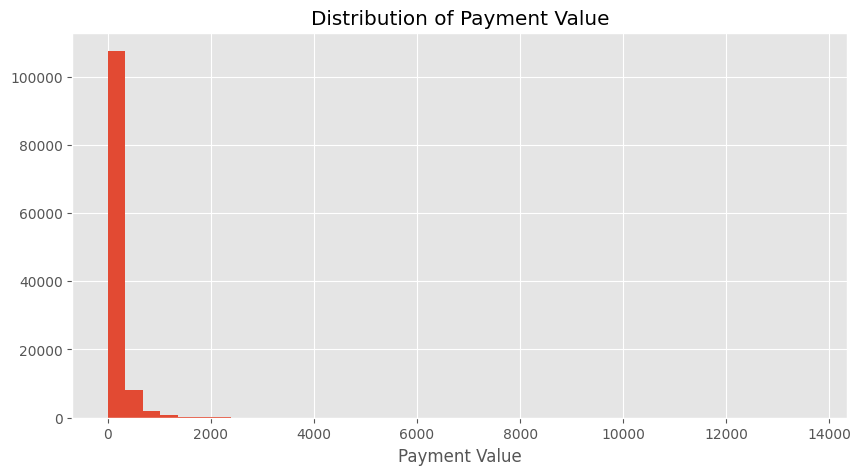

In [120]:
plt.figure(figsize=(10,5))

master_df["payment_value"].hist(bins=40)

plt.title("Distribution of Payment Value")

plt.xlabel("Payment Value")

plt.show()

In [121]:
master_df[
    ["price",
     "payment_value",
     "payment_installments",
     "freight_value"]
].corr()

,price,payment_value,payment_installments,freight_value
price,1.000000,0.739236,0.277642,0.415938
payment_value,0.739236,1.000000,0.273647,0.373762
payment_installments,0.277642,0.273647,1.000000,0.185674
freight_value,0.415938,0.373762,0.185674,1.000000


In [122]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "order_delivered_carrier_date"
]

for col in date_cols:
    master_df[col] = pd.to_datetime(master_df[col])

In [123]:
master_df["delivery_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.days

In [124]:
master_df["shipping_days"] = (
    master_df["order_delivered_carrier_date"]
    - master_df["order_purchase_timestamp"]
).dt.days

In [125]:
master_df["delivery_delay"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_estimated_delivery_date"]
).dt.days

In [126]:
master_df["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [127]:
master_df["delivery_days"].mean()

np.float64(12.022588617548953)

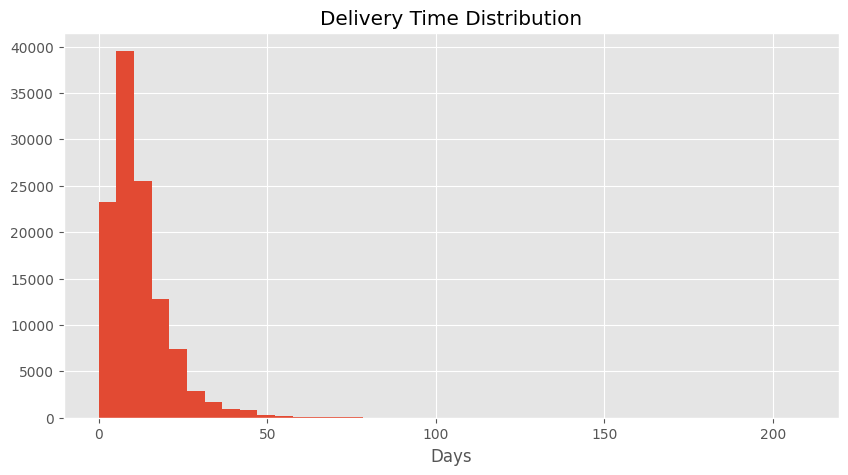

In [128]:
plt.figure(figsize=(10,5))

master_df["delivery_days"].hist(bins=40)

plt.title("Delivery Time Distribution")

plt.xlabel("Days")

plt.show()

In [129]:
state_delivery = (
    master_df.groupby("customer_state")["delivery_days"]
    .mean()
    .sort_values(ascending=False)
)

state_delivery

customer_state
RR    27.826087
AP    27.662651
AM    26.064706
AL    24.128090
PA    23.268004
MA    21.191981
SE    20.886010
CE    20.344415
AC    20.170213
PB    20.107372
RO    19.234875
RN    19.184725
PI    18.893502
BA    18.734684
PE    17.765217
MT    17.522181
TO    16.664671
ES    15.235116
MS    15.057783
GO    14.903967
RJ    14.774957
RS    14.703888
SC    14.513443
DF    12.501430
PR    11.523074
MG    11.499963
SP     8.274160
Name: delivery_days, dtype: float64

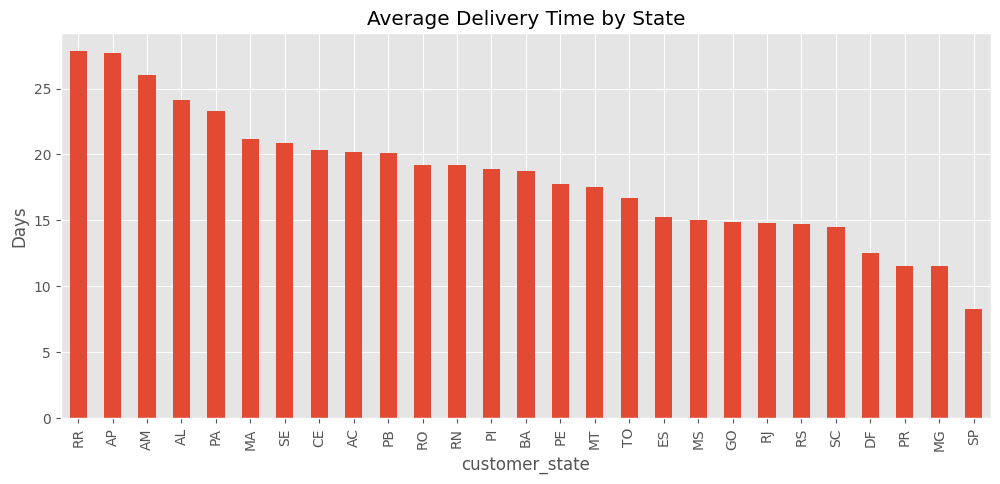

In [130]:
plt.figure(figsize=(12,5))

state_delivery.plot(kind="bar")

plt.title("Average Delivery Time by State")

plt.ylabel("Days")

plt.show()

In [131]:
master_df["late_delivery"] = (
    master_df["delivery_delay"] > 0
)

In [132]:
master_df["late_delivery"].value_counts()

late_delivery
False    111584
True       7559
Name: count, dtype: int64

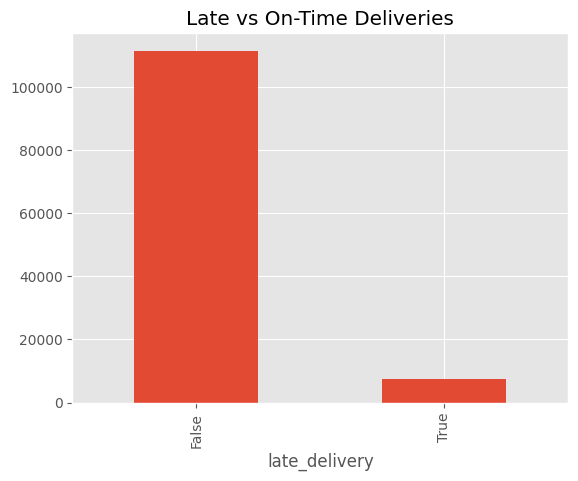

In [133]:
master_df["late_delivery"].value_counts().plot(
    kind="bar"
)

plt.title("Late vs On-Time Deliveries")

plt.show()

In [134]:
master_df["delivery_delay"].mean()

np.float64(-12.04839183560602)

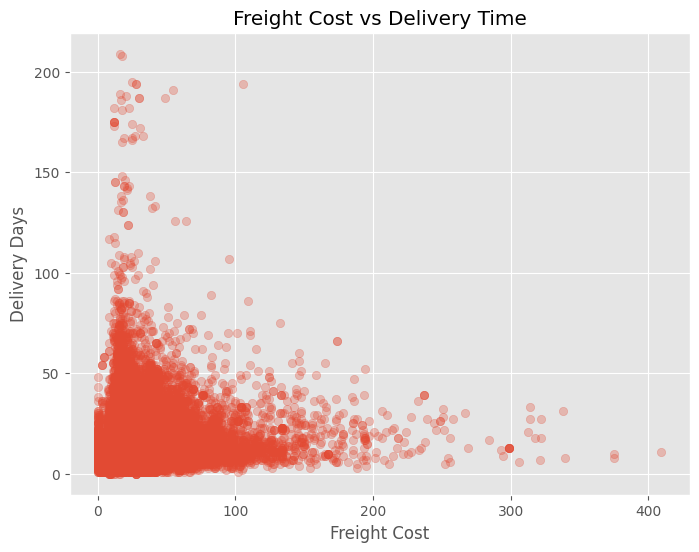

In [135]:
plt.figure(figsize=(8,6))

plt.scatter(
    master_df["freight_value"],
    master_df["delivery_days"],
    alpha=0.3
)

plt.xlabel("Freight Cost")

plt.ylabel("Delivery Days")

plt.title("Freight Cost vs Delivery Time")

plt.show()

In [136]:
master_df[
    ["delivery_days",
     "delivery_delay",
     "freight_value",
     "price"]
].corr()

,delivery_days,delivery_delay,freight_value,price
delivery_days,1.000000,0.598278,0.212870,0.061389
delivery_delay,0.598278,1.000000,-0.040571,-0.003150
freight_value,0.212870,-0.040571,1.000000,0.415938
price,0.061389,-0.003150,0.415938,1.000000


In [137]:
seller_delivery = (
    master_df.groupby("seller_id")["delivery_days"]
    .mean()
    .sort_values()
)

seller_delivery.head(10)

seller_id
6561d6bf844e464b4019442692b40e02    1.0
139157dd4daa45c25b0807ffff348363    1.0
96f7c797de9ca20efbe14545bed63eec    1.0
2c00c85d30361cd2ced2969cffbbffa3    1.0
5e063e85d44b0f5c3e6ec3131103a57e    1.0
674207551483fec113276b67b0d871ff    1.0
702835e4b785b67a084280efca355756    1.0
f3511c85f59f8dec53d140501ee8e7a8    1.0
751e274377499a8503fd6243ad9c56f6    1.0
734def04b237117a09321dd6d8f3f2a2    1.5
Name: delivery_days, dtype: float64

In [138]:
seller_delivery.tail(10)

seller_id
f5403d3f50089112c4eed37928b7f622   NaN
f543ba3c973276f519d89d59bd46cead   NaN
f7df46c1e0ec44eed5c6726478da4a17   NaN
f9a02f1922d1de564392e656d82b3fda   NaN
f9eda05b67bef472deaddbba84aca289   NaN
fa18c782a4866d313cadab567097f8f1   NaN
fa7ad8ae9bcb2c4493fdf38e96b1d74f   NaN
fc99f99385ae90f66f01733856fb88c9   NaN
fec6912baad85d41729669edd6b4d3b8   NaN
ffcfefa19b08742c5d315f2791395ee5   NaN
Name: delivery_days, dtype: float64

In [139]:
delivery_review = (
    master_df.groupby("review_score")["delivery_days"]
    .mean()
)

delivery_review

review_score
1.0    19.099992
2.0    15.381893
3.0    13.552435
4.0    11.778330
5.0    10.203253
Name: delivery_days, dtype: float64

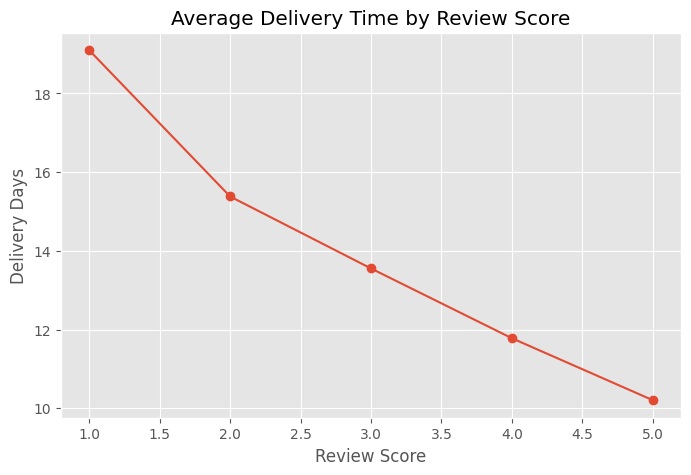

In [140]:
plt.figure(figsize=(8,5))

plt.plot(
    delivery_review.index,
    delivery_review.values,
    marker="o"
)

plt.title("Average Delivery Time by Review Score")

plt.xlabel("Review Score")

plt.ylabel("Delivery Days")

plt.show()

In [141]:
late_state = (
    master_df.groupby("customer_state")["late_delivery"]
    .mean()
    .sort_values(ascending=False)
)

late_state

customer_state
AL    0.204741
MA    0.171729
SE    0.151365
PI    0.133681
CE    0.129073
BA    0.113909
RJ    0.111741
PA    0.108060
PB    0.107143
ES    0.104661
RN    0.101045
RR    0.096154
PE    0.088667
TO    0.088235
MS    0.085847
SC    0.079632
GO    0.058800
MT    0.056537
DF    0.056439
RS    0.056291
MG    0.042116
SP    0.041858
PR    0.037730
RO    0.037671
AP    0.035714
AC    0.031579
AM    0.028902
Name: late_delivery, dtype: float64

In [142]:
review_dist = (
    master_df["review_score"]
    .value_counts()
    .sort_index()
)

review_dist

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

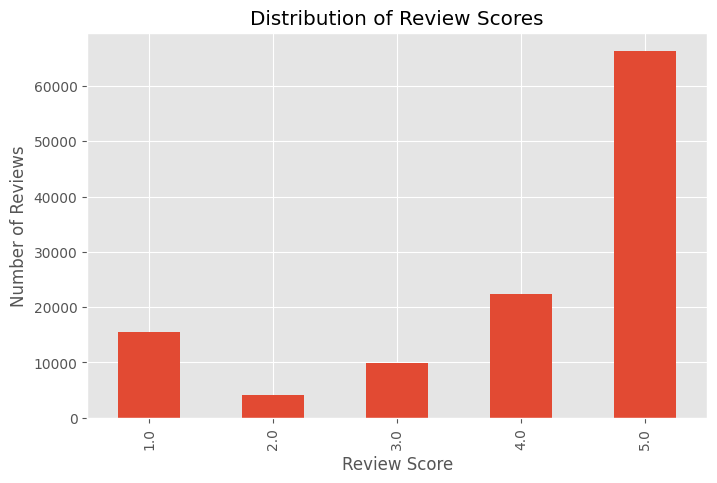

In [143]:
plt.figure(figsize=(8,5))

review_dist.plot(kind="bar")

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [144]:
master_df["review_score"].mean()

np.float64(4.015582414978078)

In [145]:
category_rating = (
    master_df.groupby("product_category_name")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

category_rating.head(10)

product_category_name
cds_dvds_musicais                     4.642857
fashion_roupa_infanto_juvenil         4.500000
livros_interesse_geral                4.438503
flores                                4.419355
livros_importados                     4.419355
construcao_ferramentas_ferramentas    4.415842
livros_tecnicos                       4.375465
alimentos_bebidas                     4.324138
portateis_casa_forno_e_cafe           4.320513
malas_acessorios                      4.295945
Name: review_score, dtype: float64

In [ ]:
category_rating.tail(10)

product_category_name
moveis_colchao_e_estofado                        3.804878
fashion_roupa_feminina                           3.780000
telefonia_fixa                                   3.672862
casa_conforto_2                                  3.642857
fashion_roupa_masculina                          3.548611
moveis_escritorio                                3.526791
portateis_cozinha_e_preparadores_de_alimentos    3.266667
fraldas_higiene                                  3.256410
pc_gamer                                         3.100000
seguros_e_servicos                               2.500000
Name: review_score, dtype: float64

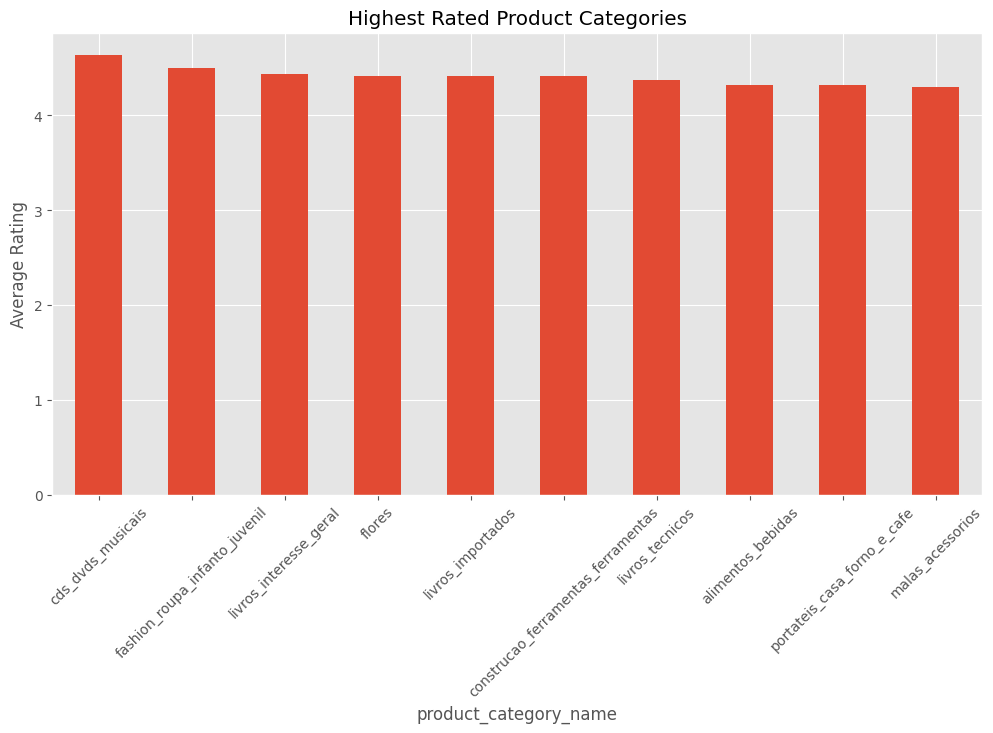

In [147]:
plt.figure(figsize=(12,6))

category_rating.head(10).plot(kind="bar")

plt.title("Highest Rated Product Categories")

plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.show()

In [148]:
seller_rating = (
    master_df.groupby("seller_id")["review_score"]
    .mean()
)

seller_rating.describe()

count    3090.000000
mean        3.972837
std         0.973487
min         1.000000
25%         3.714286
50%         4.166667
75%         4.617081
max         5.000000
Name: review_score, dtype: float64

In [149]:
seller_rating.sort_values(
    ascending=False
).head(10)

seller_id
c3251e13f1bbda6c74e37c160f991e19    5.0
3986c0b54f6b748b75e7bd4e092aa3e5    5.0
39a5005f2605cbdb4f9ac14485cabfd1    5.0
95cca791657aabeff15a07eb152d7841    5.0
d149de2f383552baea37a7198c2296ce    5.0
94d76e96eedd976258cd3278ce56d5f2    5.0
94ca168e8bcb407ab85c5da308863027    5.0
3ac588cd562971392504a9e17130c40b    5.0
93bef6edaa84956e8e575016449b6351    5.0
3b18f9856c6eb2413eafedb58e9eecd9    5.0
Name: review_score, dtype: float64

In [150]:
delivery_rating = (
    master_df.groupby("review_score")["delivery_days"]
    .mean()
)

delivery_rating

review_score
1.0    19.099992
2.0    15.381893
3.0    13.552435
4.0    11.778330
5.0    10.203253
Name: delivery_days, dtype: float64

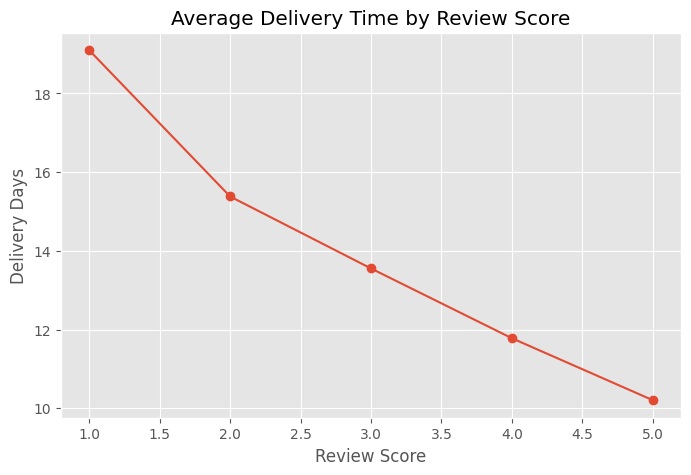

In [151]:
plt.figure(figsize=(8,5))

plt.plot(
    delivery_rating.index,
    delivery_rating.values,
    marker="o"
)

plt.title("Average Delivery Time by Review Score")

plt.xlabel("Review Score")

plt.ylabel("Delivery Days")

plt.show()

In [152]:
price_rating = (
    master_df.groupby("review_score")["price"]
    .mean()
)

price_rating

review_score
1.0    127.865836
2.0    116.824840
3.0    109.145154
4.0    119.025420
5.0    121.296862
Name: price, dtype: float64

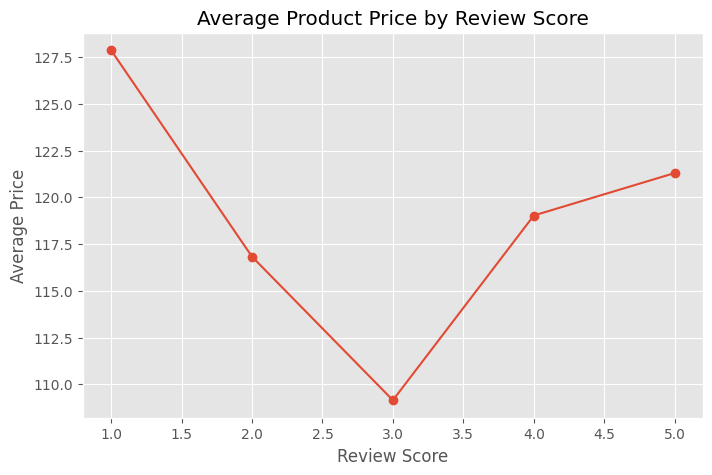

In [153]:
plt.figure(figsize=(8,5))

plt.plot(
    price_rating.index,
    price_rating.values,
    marker="o"
)

plt.title("Average Product Price by Review Score")

plt.xlabel("Review Score")

plt.ylabel("Average Price")

plt.show()

In [154]:
freight_rating = (
    master_df.groupby("review_score")["freight_value"]
    .mean()
)

freight_rating

review_score
1.0    21.337281
2.0    20.891699
3.0    20.241581
4.0    20.149423
5.0    19.607010
Name: freight_value, dtype: float64

In [155]:
late_review = (
    master_df.groupby("review_score")["late_delivery"]
    .mean()
)

late_review

review_score
1.0    0.259787
2.0    0.152811
3.0    0.078836
4.0    0.033021
5.0    0.018193
Name: late_delivery, dtype: float64

In [156]:
master_df["review_comment_message"].notnull().sum()

np.int64(50245)

In [157]:
(
    master_df["review_comment_message"].notnull().mean()
) * 100

np.float64(42.17201178415853)

In [158]:
master_df[
    [
        "review_score",
        "delivery_days",
        "delivery_delay",
        "price",
        "freight_value"
    ]
].corr()

,review_score,delivery_days,delivery_delay,price,freight_value
review_score,1.000000,-0.302750,-0.228449,-0.004492,-0.037013
delivery_days,-0.302750,1.000000,0.598278,0.061389,0.212870
delivery_delay,-0.228449,0.598278,1.000000,-0.003150,-0.040571
price,-0.004492,0.061389,-0.003150,1.000000,0.415938
freight_value,-0.037013,0.212870,-0.040571,0.415938,1.000000


Business Recommendations

Based on the analysis, the following recommendations are proposed to improve marketplace performance:

- Focus marketing efforts on high-performing product categories.
- Improve logistics in regions experiencing longer delivery times.
- Strengthen relationships with high-performing sellers.
- Investigate low-rated products and sellers to improve customer satisfaction.
- Promote preferred payment methods to simplify checkout.
- Develop retention campaigns for repeat and high-value customers.
- Use delivery performance metrics as a key operational KPI.

Conclusion

This project demonstrates an end-to-end analytics workflow, including data understanding, cleaning, integration, exploratory data analysis, visualization, and business insight generation.

The project showcases how transactional e-commerce data can be transformed into actionable insights to support data-driven decision-making across sales, customer experience, operations, and marketplace management.

### Insight

- São Paulo generated the highest revenue among all states.
- Revenue is concentrated in a small number of product categories.
- Credit cards account for the majority of transactions, indicating a strong customer preference for digital payments.